---
draft: true
---

# KL divergence: forward vs reverse

## Motivation and definition

KL-divergence is perhaps the most popular $f$-divergence. KL divergence can be thought of as the average number of extra bytes it takes to encode information from $P$ using $Q$. Concretely, it is defined as:

$$D_{KL}(P || Q) := -p(x_i)\log q(x_i) + p(x_i)\log p(x_i)$$

In this article, I will use Einstein notation and work with discrete probability distributions to keep the maths simple. The same argument can be applied to continuous probability distributions as well. To simplify our notation, we also use a $p_i$ as short hand for $p(x_i)$.

One thing to note is that KL-divergence is not symmetric: $D_{KL}(P || Q) \ne D_{KL}(Q || P)$. To make this difference explicit, $D_{KL}(P || Q)$ is called the forward-KL and $D_{KL}(Q || P)$ is the reverse KL. Note that the direction forward and reverse only makes sense if there is a reference, and the reference point that is used in AI/ML is that $P$ is the true distribution and $Q$ is the approxmiate distribution. Here are some concrete examples:

- $P$ is the probability distribution of human language, and $Q$ is the probability distribution of our model.
- $P$ is the teacher model, and $Q$ is the student model.

Both forward and reverse KL is used as a loss function in model training. The most famous case would be forward KL being used on soft distillation and reverse KL being used in RL setting. It's worth investigating further what the properties of these different KL divergences are to build an intuition.

## Forward and reverse KL

When using forward and reverse KL as a loss function, often forward KL is described as mean seeking while reverse KL described as mode seeking. Let's use an example to demonstrate this behaviour.

## Example: Fitting a single Gaussian to a Bimodal Gaussian Mixture

A classic and very effective example to illustrate this is fitting a single Gaussian distribution to a bimodal Gaussian mixture (a distribution with two peaks). 

Here is how it works conceptually:
- **True Distribution ($P$):** A mixture of two Gaussians (e.g., one peak at $x=-2$ and another at $x=2$).
- **Model Distribution ($Q$):** A single Gaussian parameterized by its mean ($\mu$) and standard deviation ($\sigma$).

When you train $Q$ to match $P$:
1. **Forward KL ($D_{KL}(P||Q)$ - Mean-Seeking):** The model $Q$ must avoid making $q_i$ small where $p_i$ is large (since $p_i \log(p_i/q_i)$ blows up if $q_i \to 0$). Therefore, the single Gaussian spreads out wide to cover *both* peaks, placing its mean in the middle (around $x=0$) even though $P$ has very low probability there.
2. **Reverse KL ($D_{KL}(Q||P)$ - Mode-Seeking):** The model $Q$ must avoid placing probability mass where $P$ has none (since $q_i \log(q_i/p_i)$ blows up if $p_i \to 0$). To avoid the "valley" between the two peaks, the single Gaussian collapses onto just *one* of the peaks and completely ignores the other.

Here is some PyTorch/Matplotlib code to demonstrate this visually:

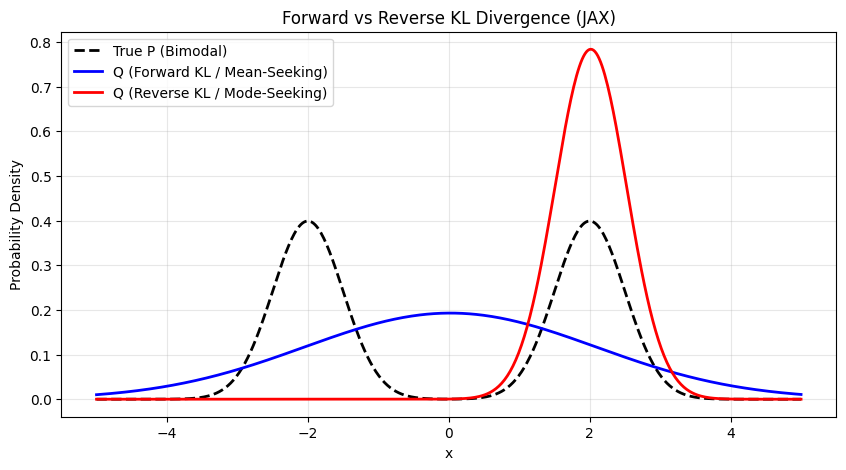

In [18]:
import jax
import jax.numpy as jnp
import jax.scipy.stats.norm as norm
import matplotlib.pyplot as plt
import optax
from jaxtyping import Array, Float, PRNGKeyArray


# 1. Define the true distribution P (Bimodal Gaussian Mixture)
def p_log_prob(x: Float[Array, "batch"]) -> Float[Array, "batch"]:
    """Calculates log P(x) using logsumexp for numerical stability."""
    log_p1 = norm.logpdf(x, loc=-2.0, scale=0.5)
    log_p2 = norm.logpdf(x, loc=2.0, scale=0.5)
    # log(0.5 * p1 + 0.5 * p2) = log(0.5) + log(e^log_p1 + e^log_p2)
    return jnp.log(0.5) + jax.nn.logsumexp(
        jnp.stack([log_p1, log_p2], axis=-1), axis=-1
    )


def sample_p(key: PRNGKeyArray, num_samples: int) -> Float[Array, "batch"]:
    """Samples from the Bimodal Gaussian Mixture P."""
    k1, k2 = jax.random.split(key)
    # Randomly select between the two modes
    modes = jax.random.choice(k1, jnp.array([-2.0, 2.0]), shape=(num_samples,))
    # Add Gaussian noise
    noise = jax.random.normal(k2, shape=(num_samples,)) * 0.5
    return modes + noise


# 2. Setup the models Q (Single Gaussians)
def q_log_prob(
    params: dict[str, Float[Array, ""]], x: Float[Array, "batch"]
) -> Float[Array, "batch"]:
    return norm.logpdf(x, loc=params["mean"], scale=jnp.exp(params["log_std"]))


def sample_q(
    params: dict[str, Float[Array, ""]], key: PRNGKeyArray, num_samples: int
) -> Float[Array, "batch"]:
    # The reparametrisation trick is implicit and "free" in JAX!
    # Because we explicitly pass the noise via the key, jax.grad
    # seamlessly differentiates through the mean and std.
    std = jnp.exp(params["log_std"])
    return params["mean"] + std * jax.random.normal(key, shape=(num_samples,))


# 3. Loss Functions
def forward_kl_loss(
    params: dict[str, Float[Array, ""]], x_p: Float[Array, "batch"]
) -> Float[Array, ""]:
    # Minimising E_P[-log Q(x)]
    return -jnp.mean(q_log_prob(params, x_p))


def reverse_kl_loss(
    params: dict[str, Float[Array, ""]], key: PRNGKeyArray, num_samples: int
) -> Float[Array, ""]:
    x_q = sample_q(params, key, num_samples)
    # Exact entropy of a Normal distribution to avoid zero-gradients
    entropy = 0.5 + 0.5 * jnp.log(2 * jnp.pi) + params["log_std"]
    return -entropy - jnp.mean(p_log_prob(x_q))


# 4. Define JIT-compiled update steps
# @jax.jit compiles these pure functions to highly efficient XLA code
@jax.jit
def update_fwd(
    params: dict[str, Float[Array, ""]],
    opt_state: optax.OptState,
    x_p: Float[Array, "batch"],
) -> tuple[dict[str, Float[Array, ""]], optax.OptState, Float[Array, ""]]:
    loss, grads = jax.value_and_grad(forward_kl_loss)(params, x_p)
    updates, new_opt_state = optimiser.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss


@jax.jit
def update_rev(
    params: dict[str, Float[Array, ""]],
    opt_state: optax.OptState,
    key: PRNGKeyArray
) -> tuple[dict[str, Float[Array, ""]], optax.OptState, Float[Array, ""]]:
    loss, grads = jax.value_and_grad(reverse_kl_loss)(params, key, 1000)
    updates, new_opt_state = optimiser.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss


# 5. The training Loop

def training_loop() -> tuple[dict[str, Float[Array, ""]], dict[str, Float[Array, ""]]]:
    # Parameters are just plain dictionaries in JAX
    params_fwd = {"mean": jnp.array(1.0), "log_std": jnp.array(0.0)}
    params_rev = {"mean": jnp.array(1.0), "log_std": jnp.array(0.0)}

    optimiser = optax.adam(learning_rate=0.05)

    # Optimisers hold state (like momentum), which we must manage explicitly
    opt_state_fwd = optimiser.init(params_fwd)
    opt_state_rev = optimiser.init(params_rev)

    key = jax.random.PRNGKey(42)
    epochs = 1000

    for _ in range(epochs):
        # We must explicitly split the key every time we need new random numbers
        key, p_key, rev_key = jax.random.split(key, 3)

        x_p = sample_p(p_key, 1000)

        params_fwd, opt_state_fwd, loss_fwd = update_fwd(params_fwd, opt_state_fwd, x_p)
        params_rev, opt_state_rev, loss_rev = update_rev(params_rev, opt_state_rev, rev_key)

    return params_fwd, params_rev

# 6. Run and plot the results

params_fwd, params_rev = training_loop()

x = jnp.linspace(-5, 5, 500)

# JAX arrays play nicely with matplotlib natively
y_p = jnp.exp(p_log_prob(x))
y_q_fwd = jnp.exp(q_log_prob(params_fwd, x))
y_q_rev = jnp.exp(q_log_prob(params_rev, x))

plt.figure(figsize=(10, 5))
plt.plot(x, y_p, label="True P (Bimodal)", color="black", linewidth=2, linestyle="--")
plt.plot(x, y_q_fwd, label="Q (Forward KL / Mean-Seeking)", color="blue", linewidth=2)
plt.plot(x, y_q_rev, label="Q (Reverse KL / Mode-Seeking)", color="red", linewidth=2)

plt.title("Forward vs Reverse KL Divergence")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Note that $\lim_{r\rightarrow 0} -\log r = \infty$. This leads to behaviour that people call mode-seeking. If we were to use reverse KL as our loss function, the model $Q(x)$ does everything in its power to avoid making $r(x) = p(x) / q(x)$ approach zero. In other words, when $p(x)$ is small, $q(x)$ must also be small, which forces the distribution to avoid spreading out wide, and avoids assigning any probability to regions where $p(x)$ is small.

To contrast with this behaviour, often people say training on forward KL is mean-seeking, where $Q(x)$ will spread across to cover $P(x)$ as much as possible.

## Estimating forward and reverse KL

In real life, we often cannot compute the probability distribution exactly, but only sample from it. How can we estimate forward and reverse KL with just a sample of the distribution? Recall that the f-functions for forward and reverse KL are:

$$
\begin{aligned}
f_{\text{forward}}(r) & := r\log r \\
f_{\text{reverse}}(r) & := -\log r
\end{aligned}
$$

Evaluating these functions directly and computing the expectation will eventually give us the correct answer, but note that the functions can produce negative values, while KL divergence is always non-negative. In other words, these function estimates are unbiased but have high variance. A classic solution to adjusting the variance is to add a term that has an expected value of zero but can correct the early behaviour with small samples. In this case, we want to correct the behaviour where using the f-functions directly can produce negative numbers. We have one natural quantity whose expected value is zero: $\mathbb{E}_Q[r-1] = 0$. We can add this to the f-functions with a multiplier $\lambda$:

$$
\begin{aligned}
\tilde{f}_{\text{forward}}(r) & := r\log r + \lambda_1 (r - 1) \\
\tilde{f}_{\text{reverse}}(r) & := -\log r + \lambda_2 (r - 1)
\end{aligned}
$$

Now the task is to pick $\lambda_1$ and $\lambda_2$ so that the modified $\tilde{f}$ function will always be non-negative. We can eyeball the solution from looking at the graph or taking the derivative to find $\lambda$ like in the Lagrange multiplier method. In our case, the solution is almost readable from the graph:

$$
\begin{aligned}
\tilde{f}_{\text{forward}}(r) & := r\log r - (r - 1) \\
\tilde{f}_{\text{reverse}}(r) & := -\log r + (r - 1)
\end{aligned}
$$

Here is an explicit computation to compare $f$ and $\tilde{f}$:

In [14]:
import torch.distributions as dis

p = dis.Normal(loc=0, scale=1)
q = dis.Normal(loc=0.1, scale=1)
x = q.sample(sample_shape=(10_000_000,))

true_kl = dis.kl_divergence(p, q)
logr = p.log_prob(x) - q.log_prob(x)

forward = logr.exp() * logr - (logr.exp() - 1)
reverse = -logr + (logr.exp() - 1)

print(f"{true_kl=}")
print(f"{forward.mean()=} {forward.std()=}")
print(f"{reverse.mean()=} {reverse.std()=}")

true_kl=tensor(0.0050)
forward.mean()=tensor(0.0050) forward.std()=tensor(0.0072)
reverse.mean()=tensor(0.0050) reverse.std()=tensor(0.0071)
